In [11]:
import numpy as np
import seaborn as sns#
import matplotlib.pyplot as plt

In [12]:
s1 = np.zeros((100,))
s2 = np.zeros((100,))
s3 = np.zeros((100,))
dt = 0.1

# s1 should have spikes in a high frequency pattern, s2 medium frequency and s3 low frequency
for i in range(100):
    if i % 5 == 0:
        s1[i] = 1
    if i % 10 == 0:
        s2[i] = 1
    if i % 20 == 0:
        s3[i] = 1
time = np.arange(0, 10, dt)

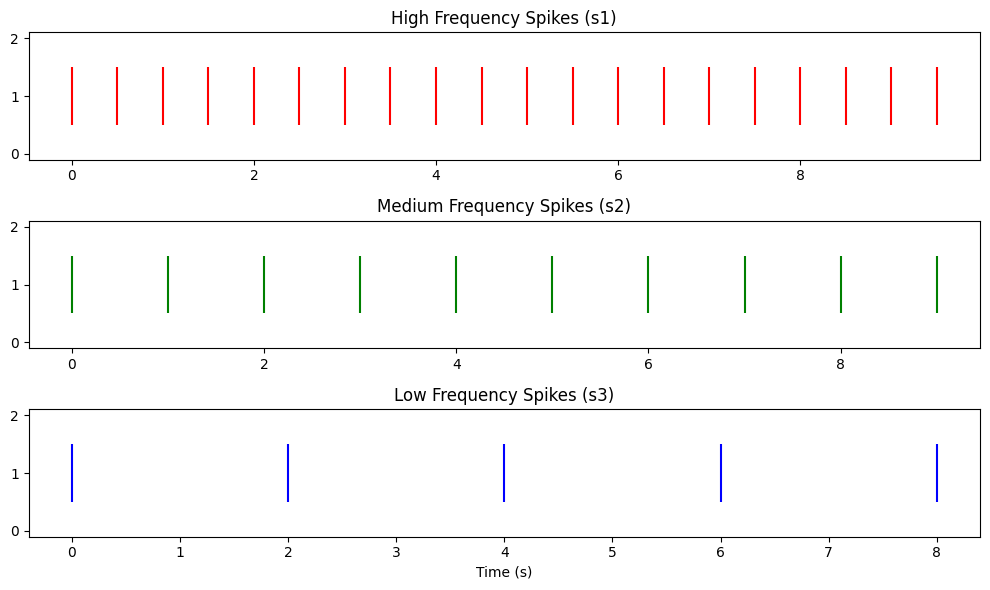

In [21]:
# use seaborn, nice plot very every spike is a vertical line, 3 different plots for s1, s2, s3, different colors
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.eventplot(np.where(s1 == 1)[0] * dt, lineoffsets=1, colors='r')
plt.title('High Frequency Spikes (s1)')
plt.subplot(3, 1, 2)
plt.eventplot(np.where(s2 == 1)[0] * dt, lineoffsets=1, colors='g')
plt.title('Medium Frequency Spikes (s2)')
plt.subplot(3, 1, 3)
plt.eventplot(np.where(s3 == 1)[0] * dt, lineoffsets=1, colors='b')
plt.title('Low Frequency Spikes (s3)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# SE-adLIF
Visualizing Spike Frequency Adaptation (SFA)

In [31]:
# we want to simulate for 10 seconds with a resolution of 1kHz so we need a dt of 0.001
dt = 0.001
time = 10
num_steps = int(time / dt)

In [32]:
alpha = np.exp(-dt / 20)
beta = np.exp(-dt / 5)
a = 100 # in the adlif its range is [0.0, 1.0]
b = 10 # in the adlif its range is [0.0, 2.0]
# state space formulation of adlif
A = np.array([[alpha, -(1-alpha)],
              [a*(1-beta)*alpha, beta-a*(1-beta)*(1-alpha)]])
B = np.array([[1-alpha, 0], [0, b*(1-beta)]])

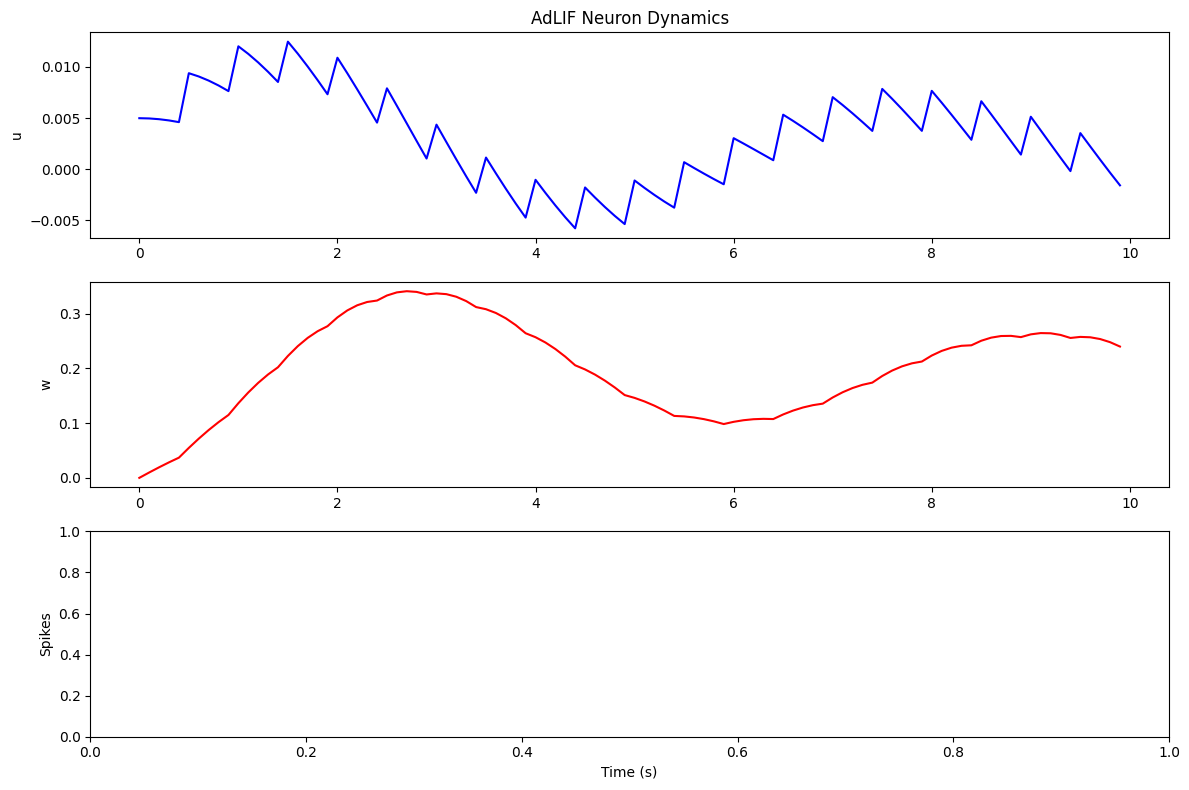

In [ ]:
u_thr = 1.0
u_adlif = 0.0
w_adlif = 0.0
u_trace = np.zeros((100,))
w_trace = np.zeros((100,))
spike_trace = np.zeros((100,))

for t in range(len(time)):
    u_adlif = alpha * u_adlif + (1 - alpha) * (-w_adlif + (s1[t]))
    w_adlif = beta * w_adlif + (1 - beta) * (a * u_adlif + b * spike_trace[t-1] if t > 0 else 0)
    if u_adlif >= u_thr:
        spike_trace[t] = 1
        u_adlif = 0.0  # Optionally reset membrane potential on spike
    else:
        spike_trace[t] = 0
    u_trace[t] = u_adlif
    w_trace[t] = w_adlif

# Plot the results
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(time, u_trace, label='Excitatory Variable (u)', color='b')
plt.title('AdLIF Neuron Dynamics')
plt.ylabel('u')
plt.subplot(3, 1, 2)
plt.plot(time, w_trace, label='Inhibitory Variable (w)', color='r')
plt.ylabel('w')
plt.subplot(3, 1, 3)
plt.eventplot(np.where(spike_trace == 1)[0] * dt, lineoffsets=1, colors='k')
plt.ylabel('Spikes')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()